In [ ]:
# Importation des différentes librairies utiles pour le notebook
# Gestion des warnings
import warnings                   # Masquer certains avertissements
warnings.filterwarnings("ignore", category=FutureWarning)

# Manipulation de données
import pandas as pd               # Tables et opérations sur les données

# Visualisation
import seaborn as sns             # Visualisation statistique
import matplotlib.pyplot as plt   # Graphiques de base

# Prétraitement (Scikit-learn)
from sklearn.preprocessing import LabelEncoder  # Encodage de variables
from sklearn.preprocessing import StandardScaler # Normalisation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold


# Système
import sys                        # Informations sur l'environnement

from pathlib import Path  # Manipulation de chemins de fichiers
import json

# Librairies générales
import numpy as np  # Calcul numérique et manipulation de tableaux
import string  # Gestion des chaînes de caractères
import re  # Expressions régulières
import emoji  # Gestion des emojis
import unicodedata  # Normalisation des caractères Unicode
import contractions  # Gestion des contractions dans le texte
from collections import Counter  # Comptage des occurrences d'éléments
import os

# Librairies d’affichage
import matplotlib.pyplot as plt  # Création de graphiques statiques
import plotly.graph_objs as go  # Création de graphiques personnalisés avec Plotly
import plotly.offline as py  # Mode offline pour afficher les graphiques Plotly
import plotly.express as px  # Visualisation simplifiée et rapide avec Plotly
import plotly.io as pio  # Permet de sauvegarder les graphiques sous forme d’images


# Librairies SpaCy pour le traitement du langage naturel
import spacy  # Bibliothèque NLP avancée
from spacy import displacy  # Visualisation d'analyse syntaxique et d'entités nommées
from spacy.lang.fr import French  # Modèle pour le français
from spacy.tokenizer import Tokenizer
# Chargement du modèle SpaCy pour l’anglais
nlp = spacy.load("en_core_web_sm")  # Modèle de base en anglais

# # Librairies NLTK pour la tokenisation, lemmatisation et analyse grammaticale
# import nltk  # Bibliothèque NLP (Natural Language Processing)
# from nltk import sent_tokenize, word_tokenize, pos_tag  # Tokenisation et étiquetage grammatical
# from nltk.stem import WordNetLemmatizer  # Lemmatisation
# from nltk.stem.snowball import SnowballStemmer  # Stemmatisation basée sur l’algorithme Snowball
# from nltk.corpus import stopwords  # Liste de mots vides (stopwords)

# # Téléchargement des ressources nécessaires pour NLTK
# nltk.download('punkt')  # Tokenisation de phrases et de mots
# nltk.download('punkt_tab') # Tokenisation de phrases et de mots
# nltk.download('averaged_perceptron_tagger') # Tags
# nltk.download('averaged_perceptron_tagger_eng') # Tags anglais
# nltk.download('tagsets_json') # Liste des tags
# nltk.download('tagsets')  # Ancienne liste des tags
# nltk.download("stopwords")  # Liste des stopwords
# nltk.download('wordnet')  # Chargement de wordnet

# nltk.download('averaged_perceptron_tagger')  # Étiquetage grammatical
# nltk.download("stopwords")  # Liste des mots vides
# nltk.download('wordnet')  # Lemmatisation
from os import sep
from os import pipe

#!pip install imbalanced-learn
import imblearn
print(imblearn.__version__)
import pandas as pd
from imblearn.over_sampling import SMOTE
from collections import Counter

0.14.1


In [ ]:
df = pd.read_csv(".." + sep + ".." + sep + "matrices" + sep + "donnees" + sep + "scitweets_export.tsv", sep='\t')
#train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
#train_df.to_csv(".." + sep + ".." + sep + "matrices" + sep + "donnees" + sep + "train.csv", index=False)
#test_df.to_csv(".." + sep + ".." + sep + "matrices" + sep + "donnees" + sep + "test.csv", index=False)

In [26]:
###########################
## Nettoyage des données ##
###########################

def nettoyage_donnée(tweet, replace_urls, replace_mentions, replace_emojis, replace_hashtags, remove_punctuation):
    # Sécurité : si la ligne est vide ou n'est pas du texte
    if not isinstance(tweet, str):
        return ""
        
    tweet = tweet.lower()
    
    if replace_urls:
        tweet = re.sub(r'http\S+', 'url', tweet) # Remplace les URLs par "URL"
    if replace_mentions:
        tweet = re.sub(r'@\w+', 'USER', tweet) # Remplace les mentions d'utilisateur par "USER"
    if replace_emojis:
        tweet = emoji.replace_emoji(tweet, replace=' EMOJI ') # Remplace les emojis par "EMOJI"
    if replace_hashtags == 1:
        tweet = re.sub(r'#(\w+)', r'hashtag_\1', tweet) # Remplace les hashtags par "hashtag_mot"
    if replace_hashtags == 2:
        tweet = re.sub(r'#(\w+)', 'HASHTAG', tweet) # Remplace les hashtags par "HASHTAG"
    if replace_hashtags == 3:
        pass # Ne fait rien, les hashtags restent tels quels
    if remove_punctuation:
        tweet = re.sub(r'[^\w\s]', '', tweet) # Supprime la ponctuation
    
    tweet = unicodedata.normalize('NFKD', tweet).encode('ascii','ignore').decode('utf-8')
    # On fait passer dans Spacy le GOAT
    # nlp crée un pipeline : il tokenise, étiquetage grammatical(tag), lemnise, voit les stopwords... le GOAT quoi
    doc = nlp(tweet)
    
    # On lui dit ce qu'on veut récup
    tokens = []

    for token in doc:
        t = token.lemma_ 
        if (not token.is_stop and 
            (token.pos_ in ['NOUN', 'ADJ', 'VERB', 'PROPN'] or "hashtag_" in t or 
         t == "emoji") and 
            len(t) > 2):
            
            tokens.append(t)
    
    return tokens


class TextNormalizer(BaseEstimator, TransformerMixin):
    def __init__(self, replace_urls, replace_mentions, replace_emojis, replace_hashtags, remove_punctuation):
        self.replace_urls = replace_urls
        self.replace_mentions = replace_mentions
        self.replace_emojis = replace_emojis
        self.replace_hashtags = replace_hashtags
        self.remove_punctuation = remove_punctuation

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [nettoyage_donnée(tweet,
                self.replace_urls,
                self.replace_mentions,
                self.replace_emojis,
                self.replace_hashtags,
                self.remove_punctuation) for tweet in X]



In [27]:

#Fonctions d'équilibrage des classes
#Matrice Upsampling - copy
def umpsampling_copy(df_matrice, nom_fichier):
    df_ones = df_matrice[df_matrice['science_related'] == 1]

    n_a_ajouter = 765 - 375
    df_extra = df_ones.sample(n=n_a_ajouter, replace=True, random_state=42)

    df_matriceCopie = pd.concat([df_matrice, df_extra], ignore_index=True)
    df_matriceCopie.to_csv(".." + sep + ".." + sep +"matrices" + sep + nom_fichier, sep=';', index=False)


#Matrice Downsampling
def downsampling(df_matrice, nom_fichier):
    df_ones = df_matrice[df_matrice['science_related'] == 1]
    df_zeros = df_matrice[df_matrice['science_related'] == 0]
    
    n_a_garder = 375 
    
    df_zeros_reduit = df_zeros.sample(n=n_a_garder, random_state=42)
    df_matriceDownsampling = pd.concat([df_zeros_reduit, df_ones], ignore_index=True)
    df_matriceDownsampling.to_csv(".." + sep + ".." + sep +"matrices" + sep + nom_fichier, sep=';', index=False)


#Matrice Upsampling - SMOTE
def umpsampling_SMOTE(df, nom_fichier):
    df = df.copy()

    y = df['science_related'] 
    X = df.drop(columns=['science_related', 'tweet_id', 'scientific_context', 'scientific_reference', 'scientific_claim'], errors='ignore')

    method = SMOTE(random_state=42)
    X_resampled, y_resampled = method.fit_resample(X, y)

    df_final = pd.DataFrame(X_resampled, columns=X.columns)
    df_final['science_related'] = y_resampled

    df_final.to_csv(".." + sep + ".." + sep + "matrices" + sep + nom_fichier, sep=';', index=False)
 

In [ ]:
def generer_matrice(dataframe, urls, mentions, emojis, hashtags, punct, min_df, max_df, ngrams, equilibrage, is_train, pipe=None):
    params = locals()
    params.pop("dataframe")
    if "pipe" in params:
        params.pop("pipe")

    ###
    # Adri2 - gestion de la sauvegarde
    ###
    
    current_file = Path().resolve() # chemin du fichier actuel
    ROOT = current_file.parent.parent
    nom_fichier = input("nom de la matrice : ")

    def is_file_exists(nom_fichier) -> str:
        csv_path = ROOT / "matrices" / (nom_fichier + ".csv")
        json_path = ROOT / "matrices" / (nom_fichier + ".json")

        if csv_path.exists() or json_path.exists():
            print(f"Erreur : Le fichier '{nom_fichier}' existe déjà.")
            new_name = input("Veuillez entrer un nouveau nom de fichier (sans extension) : ")

            return is_file_exists(new_name)
        else:
            # Procéder à l'écriture
            params["file_name"] = str(Path(*json_path.parts[json_path.parts.index("src"):]))
            with json_path.open("w", encoding="utf-8") as f:
                json.dump(params, f, indent=4, ensure_ascii=False)
            return nom_fichier
    
    nom_fichier = is_file_exists(nom_fichier=nom_fichier) + ".csv"
    
    
    df = dataframe.copy()
    df['text_clean'] = df['text'].apply(lambda x: nettoyage_donnée(x, urls, mentions, emojis, hashtags, punct))
    df = df[df['text_clean'].map(len) > 0].copy()
    
    
    if is_train:
        pipe = Pipeline([("cleaner", TextNormalizer(
        replace_urls=urls,
        replace_mentions=mentions,
        replace_emojis=emojis,
        replace_hashtags=hashtags,
        remove_punctuation=punct
        )),
        ("vectorizer", TfidfVectorizer(lowercase=False,
                                       preprocessor=None,
                                       tokenizer=lambda x: x,
                                       token_pattern=None,
                                       max_df=max_df,  # Ignorer les termes présents dans plus de 90% des documents
                                       min_df=min_df,  # Ignorer les termes présents dans moins de 2 tweets
                                       ngram_range=ngrams,
                                       ))])
        transformed_text = pipe.fit_transform(df['text'])
    
    else:
        transformed_text = pipe.transform(df['text'])

    df_pipe = pd.DataFrame(
        data=transformed_text.toarray(),
        columns=pipe['vectorizer'].get_feature_names_out()
    )

    df_pipe.insert(0, 'tweet_id', df['tweet_id'].values)
    df_pipe.insert(0, 'science_related', df['science_related'].values)
    df_pipe.insert(0, 'scientific_claim', df['scientific_claim'].values)
    df_pipe.insert(0, 'scientific_reference', df['scientific_reference'].values)
    df_pipe.insert(0, 'scientific_context', df['scientific_context'].values)

    df_visu = df[['text', 'text_clean']].copy()
    
    if equilibrage == "copy":
        umpsampling_copy(df_pipe, nom_fichier)
    elif equilibrage == "down":
        downsampling(df_pipe, nom_fichier)
    elif equilibrage == "SMOTE":
        umpsampling_SMOTE(df_pipe, nom_fichier)
    else :
         print("Aucun équilibrage appliqué.")
         df_pipe.to_csv(".." + sep + ".." + sep + "matrices" + sep + nom_fichier, sep=';', index=False)
    
    #display(df_pipe)caca
    
    return df_visu, pipe

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for i, (tr_idx, te_idx) in enumerate(cv.split(df, df['science_related'])):
    train_df = df.iloc[tr_idx]
    test_df = df.iloc[te_idx]
    _, pipe_du_tour = generer_matrice(train_df, urls=True, mentions=True, emojis=True, hashtags=1, punct=True, 
                          min_df=2, max_df=0.9, ngrams=(1, 2), equilibrage=None, is_train=True, nom_matrice=f"fold_{i+1}_train")
    _, _ = generer_matrice(test_df, urls=True, mentions=True, emojis=True, hashtags=1, punct=True, 
                          min_df=2, max_df=0.9, ngrams=(1, 2), equilibrage=None, is_train=False, pipe=pipe_du_tour, nom_matrice=f"fold_{i+1}_test")
    

# min_df = 2 # Ignorer les termes présents dans moins de 2 tweets
# max_df = 0.9 # Ignorer les termes présents dans plus de 90% des tweets
# Hashtags : 1 pour "hashtag_mot", 2 pour "HASHTAG", 3 pour "mot"
# equilibrage : "copy" pour du upsampling par copie, "down" pour du downsampling, "SMOTE" pour du upsampling par SMOTE, ou None pour aucun équilibrage
matrice_train = generer_matrice(dataframe = train_df, urls=True, mentions=True, emojis=True, hashtags=1, punct=True, 
                          min_df=2, max_df=0.9, ngrams=(1, 2), equilibrage=None, is_train=True)
matrice_test = generer_matrice(dataframe = test_df, urls=True, mentions=True, emojis=True, hashtags=1, punct=True, 
                          min_df=2, max_df=0.9, ngrams=(1, 2), equilibrage=None, is_train=False, pipe=matrice_train[1])



Aucun équilibrage appliqué.
Aucun équilibrage appliqué.


In [ ]:
pd.set_option('display.max_colwidth', None)
display(matrice_train[0][['text', 'text_clean']].head())

,text,text_clean
12,Science sucks.,"[science, suck]"
581,"@FerrickAnima @Ichikyo57 -exclusively for PS4 get backported to Vita/PS3 (RESOGUN) and that shit was not pretty. Inferior graphics, lower framerate, game was NOT--","[user, USER, ps4, backporte, vitaps3, resogun, shit, inferior, graphic, low, framerate, game]"
1003,@GreatTammie @RudeRicky @latimes Got houseless? Want to have #PublicHealth for the survival of the human species? HOUSING and HEALTHCARE! #CORONAVIRUS “Oregon’s homeless at risk for coronavirus. The crowded conditions in which the homeless live make them more susceptible to the virus.” https://t.co/KwchIaTGck,"[user, USER, USER, get, houseless, want, hashtag_publichealth, survival, human, specie, housing, healthcare, hashtag_coronavirus, oregon, homeless, risk, coronavirus, crowd, condition, homeless, live, susceptible, virus, url]"
501,"Muslims insulted by being called ""ignorant"" of the pain they inflict. https://t.co/nVveHJhC3r If not ignorant, they do it knowingly?","[muslims, insult, call, ignorant, pain, inflict, url, ignorant]"
318,Alternative Ways To Get Menstrual Pain Relief http://t.co/tsk21O2ksQ,"[alternative, way, menstrual, pain, relief, url]"


In [ ]:
# Comptage des mots
word_counts = Counter()
for mot in matrice['text_clean']:
    word_counts.update(mot)

print(word_counts.most_common(10))

[('url', 885), ('USER', 679), ('stop', 197), ('support', 168), ('report', 83), ('people', 74), ('user', 72), ('new', 67), ('cause', 63), ('increase', 52)]


In [ ]:
#Les word clouds permettent de visualiser facilement ces mots en mettant en évidence 
# ceux qui apparaissent le plus fréquemment.

top_100 = dict(word_counts.most_common(100))

# Création du word cloud avec Plotly
fig = px.treemap(
    names=list(top_100.keys()),
    parents=[""] * len(top_100),
    values=list(top_100.values()),
    title="Word Cloud interactif sous la forme d'un treemap"
)

# Mise à jour des couleurs : plus fréquents en rouge foncé, moins fréquents en bleu clair
fig.update_traces(
    marker=dict(
        colors=list(top_100.values()),
        colorscale=[(0, 'lightblue'), (0.5, 'orange'), (1, 'darkred')],  # Dégradé personnalisé
        colorbar=dict(title="Fréquence")
    )
)

fig.show()

pio.write_image(fig, 'treemap_wordcloud.png')


In [ ]:

import plotly.io as pio
fig.show()
pio.write_image(fig, "treemap_wordcloud.png")

LA MATRICE DE CORRELATION : ANALYSE DES LIENS LOGIQUES (MATRICE DE CORRÉLATION) 

Objectif : Vérifier la cohérence entre les colonnes de scores numériques.
    - Score proche de 1 : Les variables sont fortement liées (ex: claim vs related).
    - Utilité : Valider que les étiquettes humaines (labels) sont fiables.
    - Rôle : Confirmer que 'science_related' est la bonne cible (y) pour l'IA. (????)

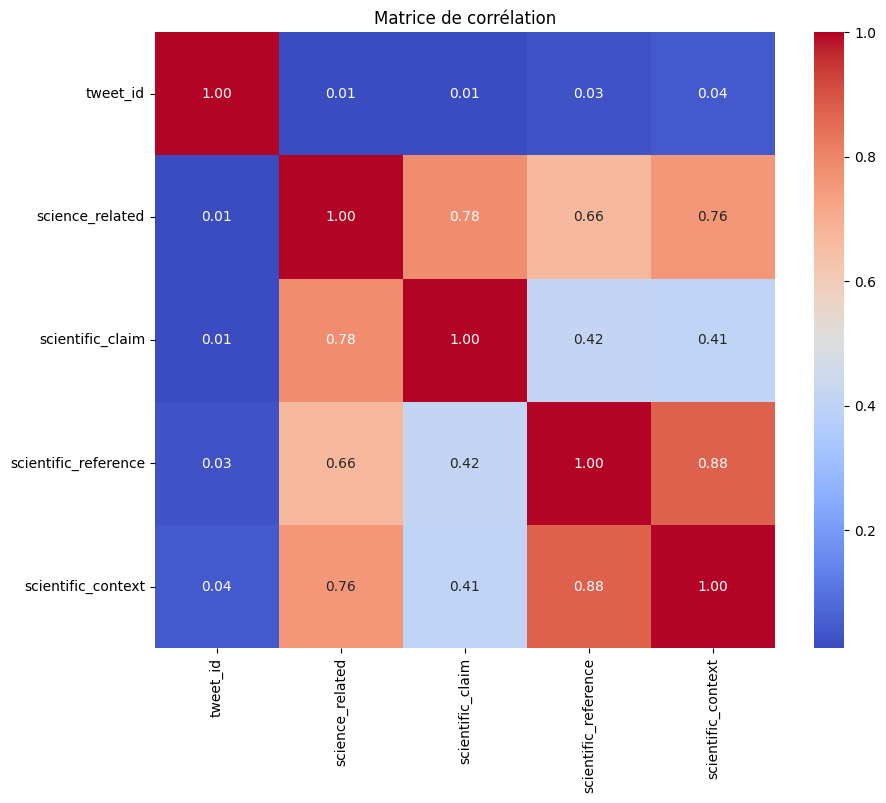

In [ ]:
df.drop(columns=["Unnamed: 0"], inplace=True)

# Sélection des colonnes numériques
num_cols = df.select_dtypes(include=["float64", "int64"])

# Calcul de la matrice de corrélation
corr_matrix = num_cols.corr()

# Affichage de la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

LA MATRICE TF-IDF : SIGNATURE NUMÉRIQUE DU TEXTE (MATRICE TF-IDF)

Objectif : Transformer les mots des tweets en "poids" mathématiques.
    - TF (Term Frequency) : Importance du mot dans le tweet local.
    - IDF (Inverse Document Frequency) : Réduit l'importance des mots trop communs.
    - Rôle : Créer les indices (X) que l'IA va utiliser pour apprendre à prédire.

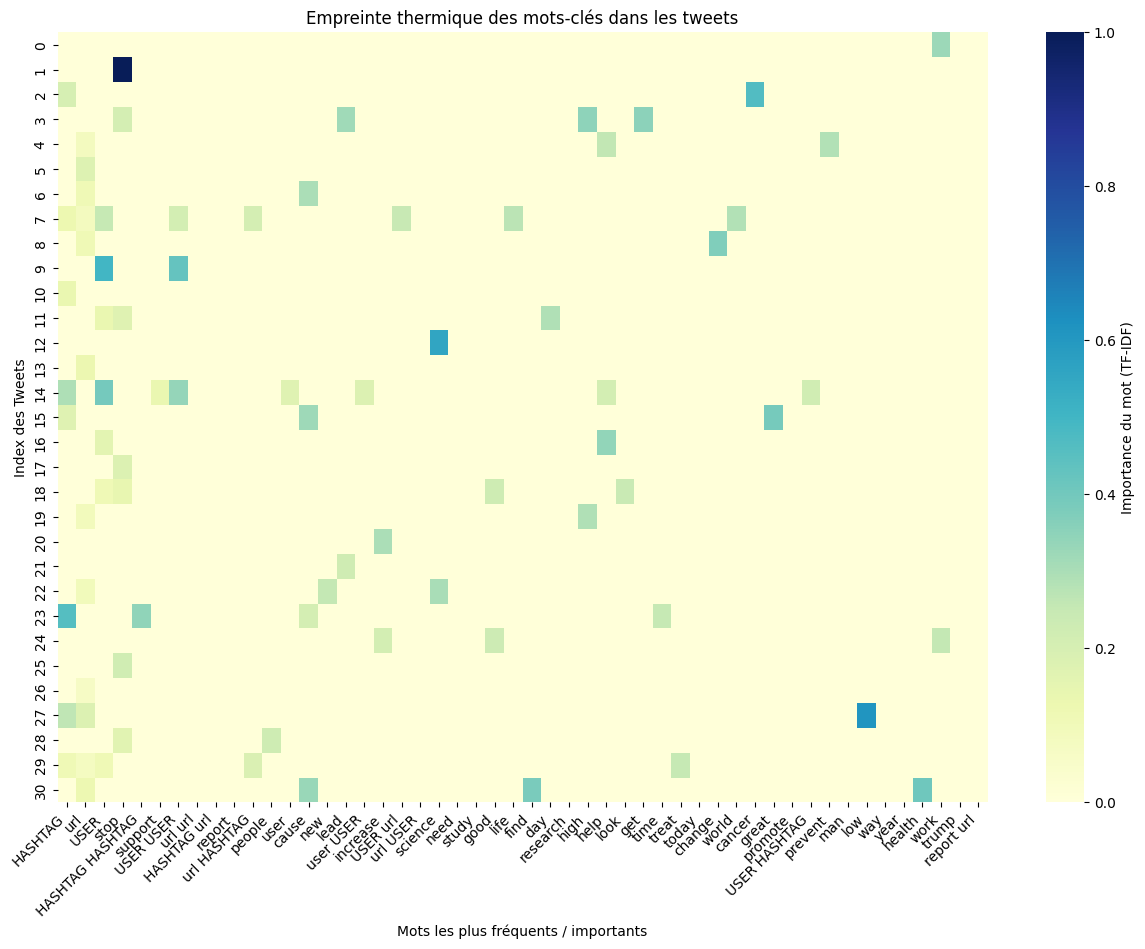

In [ ]:
# 1. On calcule l'importance totale de chaque mot (somme des scores TF-IDF)
importance_mots = df_matrice.sum().sort_values(ascending=False)

# 2. On sélectionne les 50 mots les plus "puissants"
top_50_mots = importance_mots.head(50).index

# 3. On crée un sous-ensemble de la matrice pour l'affichage (ex: les 30 premiers tweets)
df_zoom = df_matrice.loc[:30, top_50_mots]

# 4. Affichage de la Heatmap "intelligente"
plt.figure(figsize=(15, 10))
sns.heatmap(df_zoom, 
            cmap="YlGnBu",      # Couleurs allant du jaune (faible) au bleu foncé (fort)
            cbar_kws={'label': 'Importance du mot (TF-IDF)'})

plt.title("Empreinte thermique des mots-clés dans les tweets")
plt.xlabel("Mots les plus fréquents / importants")
plt.ylabel("Index des Tweets")
plt.xticks(rotation=45, ha='right') # Incliner les mots pour la lecture
plt.show()